In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("S02-hw-dataset.csv")
print(df.head())
print(df.describe())
print(df.info())

   user_id   age country  purchases  revenue
0        1  25.0      FR          7      749
1        2  24.0      RU          5     1115
2        3  52.0      FR          7      399
3        4  31.0      RU          6      654
4        5   NaN      DE          6     1296
         user_id         age  purchases      revenue
count  41.000000   39.000000  41.000000    41.000000
mean   20.243902   36.512821   4.829268   820.048780
std    11.659289   18.304259   2.710189   613.127269
min     1.000000    5.000000  -1.000000     0.000000
25%    10.000000   24.000000   3.000000   432.000000
50%    20.000000   33.000000   5.000000   693.000000
75%    30.000000   45.500000   7.000000  1115.000000
max    40.000000  120.000000  11.000000  2475.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null    

In [3]:
df.isna().count()
df.dropna()
df.duplicated()
print(df.duplicated().mean)
df = df.drop(40)
df = df[df['revenue'] > 0]
df = df[df['age'] >= 18]
df = df[df['age'] < 100]
df = df[df['purchases'] >= 0]
df

<bound method Series.mean of 0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40     True
dtype: bool>


,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
7,8,28.0,CN,2,456
8,9,39.0,US,4,980
9,10,24.0,RU,7,511
11,12,20.0,CN,7,1652
13,14,36.0,DE,9,2358
14,15,57.0,FR,7,693


в датасете был обноружен дубликат (строка 40), также были пропуски и нелогичные данные (возраст, кол-во покупок и тд.)

In [4]:
print(df['age'].value_counts())
print(df['country'].value_counts())

group_df = df.groupby('country')
print(group_df.size())
print(group_df['revenue'].mean())


df['revenue_group'] = pd.cut(df['revenue'], bins = 3, 
                              labels = ['low', 'medium', 'high'])
df

age
24.0    2
31.0    2
52.0    2
39.0    2
32.0    2
47.0    2
35.0    2
28.0    1
25.0    1
57.0    1
36.0    1
20.0    1
22.0    1
33.0    1
42.0    1
21.0    1
54.0    1
43.0    1
55.0    1
26.0    1
23.0    1
45.0    1
51.0    1
18.0    1
34.0    1
Name: count, dtype: int64
country
FR    10
RU     9
US     6
DE     5
CN     2
Name: count, dtype: int64
country
CN     2
DE     5
FR    10
RU     9
US     6
dtype: int64
country
CN    1054.000000
DE    1475.400000
FR     732.600000
RU     919.111111
US     638.166667
Name: revenue, dtype: float64


,user_id,age,country,purchases,revenue,revenue_group
0,1,25.0,FR,7,749,low
1,2,24.0,RU,5,1115,medium
2,3,52.0,FR,7,399,low
3,4,31.0,RU,6,654,low
7,8,28.0,CN,2,456,low
8,9,39.0,US,4,980,medium
9,10,24.0,RU,7,511,low
11,12,20.0,CN,7,1652,medium
13,14,36.0,DE,9,2358,high
14,15,57.0,FR,7,693,low


Описание исследования данных о покупателях

Распределение покупателей по странам:
В нашем наборе данных больше всего покупателей из Франции (10 человек) и России (9 человек) - вместе они составляют больше половины всех покупателей. На третьем месте США с 6 покупателями, затем Германия (5 покупателей) и меньше всего покупателей из Китая (всего 2 человека).

Сравнение сумм покупок по странам:
Если посмотреть на среднюю сумму покупок, то здесь картина немного меняется. Самый высокий средний чек у покупателей из Германии - 1475.4, что более чем в два раза выше, чем у покупателей из США (638.17). Покупатели из Китая показывают хороший результат (1054.0), но их всего двое, поэтому эти данные могут быть не очень надежными.

Что интересного заметили:
Особенно удивила разница между Германией и США - при почти одинаковом количестве покупателей средняя сумма покупок немецких покупателей значительно выше. Также интересно, что во Франции, где больше всего покупателей, средняя сумма покупок довольно средняя (732.6). Российские покупатели показывают стабильные результаты как по количеству, так и по средней сумме покупок.

Мы также разделили всех покупателей на три группы по уровню трат (низкий, средний, высокий), чтобы в дальнейшем можно было анализировать поведение разных категорий покупателей.

In [5]:
%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

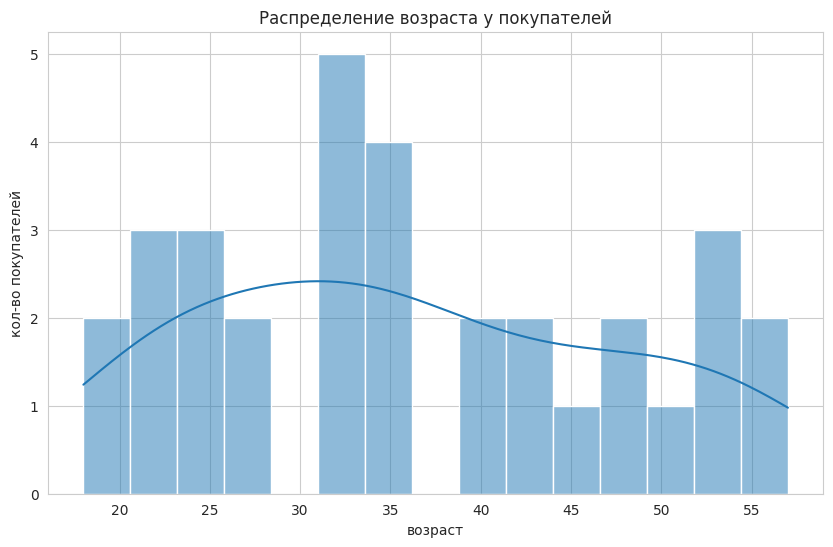

In [7]:
plt.figure(figsize = (10, 6))
sns.histplot(data = df, x = 'age', bins = 15, kde = True)
plt.title('Распределение возраста у покупателей')
plt.xlabel('возраст')
plt.ylabel('кол-во покупателей')
plt.savefig('figures/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

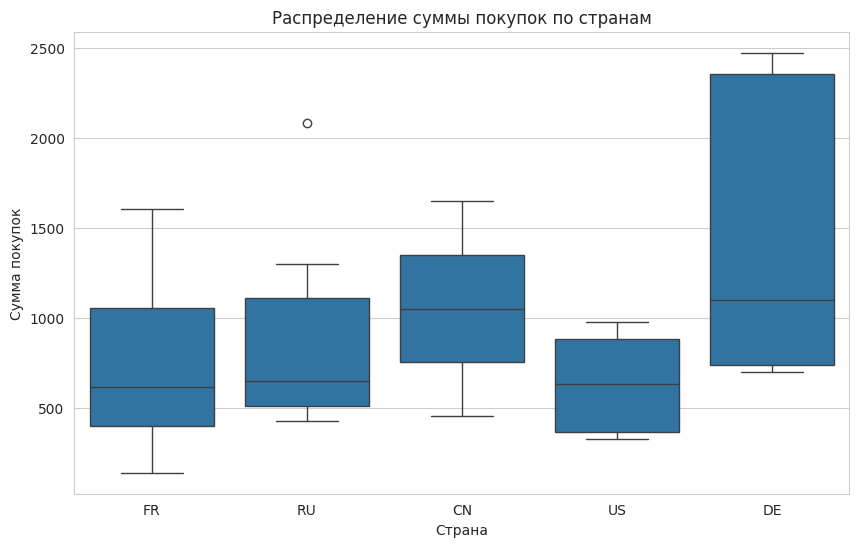

In [8]:
plt.figure(figsize = (10,6))
sns.boxplot(data = df, x = 'country', y = 'revenue')
plt.title('распределение суммы покупок по странам')
plt.xlabel('Страна')
plt.ylabel('Сумма покупок')
plt.savefig('figures/revenue_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

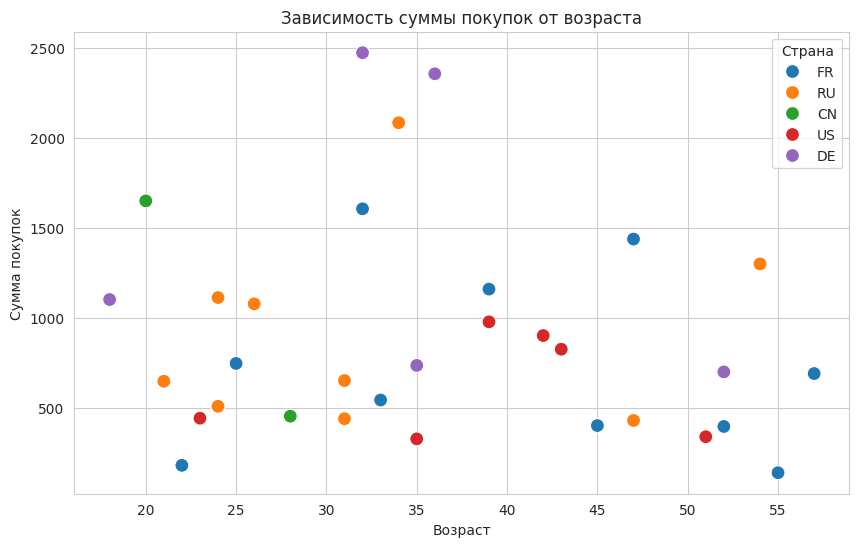

In [10]:
plt.figure(figsize = (10, 6))
sns.scatterplot(data = df, x = 'age', y='revenue', hue='country', s=100)
plt.title('Зависимость суммы покупок от возраста')
plt.xlabel('Возраст')
plt.ylabel('Сумма покупок')
plt.legend(title='Страна')
plt.savefig('figures/age_vs_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

Основные наблюдения:

По распределению покупателей доминируют Франция (10 покупателей) и Россия (9 покупателей), которые вместе составляют более половины всей выборки. США и Германия представлены средне (6 и 5 покупателей соответственно), а Китай - минимально (всего 2 покупателя), что может влиять на статистическую значимость данных по этой стране.

По средним значениям наблюдается значительная разница между странами. Германия демонстрирует самый высокий средний чек (1475.4), более чем в 2 раза превышая показатели США (638.2). При этом Франция, имея наибольшее количество покупателей, показывает относительно скромный средний доход (732.6). Российские покупатели занимают устойчивую среднюю позицию (919.1), в то время как данные по Китаю выглядят перспективно, но требуют дополнительной выборки для подтверждения.
